# Training Session 1 — Notes & Summary

**Date:** 01/24/2026  
**Objective:** Multi-stage classification of recyclable materials using a CNN-based pipeline.  
**Stages:** Stage 1 (binary recyclable/non-recyclable), Stage 2 (sub-categories — *no data*), Stage 3 (Paper, Glass, Residual, Metal sub-classifiers)

---

## Executive Summary

| Stage | Classes | Best Val Acc | Final Test Acc | Epochs |
|-------|---------|-------------|---------------|--------|
| Stage 1 — Binary | recyclable / non-recyclable | **93.0%** (Ep 24) | **92.0%** | 25 |
| Stage 3: Paper | 5 paper sub-types | **93.2%** (Ep 22) | **84.8%** | 25 |
| Stage 3: Glass | 3 glass sub-types | **99.3%** (Ep 20) | **98.7%** | 25 |
| Stage 3: Residual | 4 residual sub-types | **97.5%** (Ep 24) | **96.5%** | 25 |
| Stage 3: Metal | 3 metal sub-types | **96.7%** (Ep 25) | **97.3%** | 25 |

**Key Takeaways:**
- All stages converged successfully within 25 epochs with clear upward trends in both training and validation accuracy.
- **Glass** and **Metal** sub-classifiers achieved the highest performance, with test accuracy above 97%.
- **Paper** showed the largest gap between best validation accuracy (93.2%) and test accuracy (84.8%), suggesting the paper sub-categories are the hardest to generalise — particularly `mixed_paper`.
- **Stage 1** binary classifier performs solidly (92% test accuracy) and provides a reliable gate before sub-classification.
- Training loss decreased monotonically across all stages; validation loss followed closely, indicating no severe overfitting.

---

## Stage 1 Training — 01/24/2026

### Stage 1 Summary

**Task:** Binary classification — *recyclable* vs *non-recyclable*  
**Dataset:** 200 test samples (100 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 69.9% | 94.8% | — |
| Val Accuracy | 76.0% | 91.5% | **93.0%** (Ep 24) |
| Train Loss | 0.5988 | — | — |
| Val Loss | 0.4632 | — | — |

**Insights:**
- Strong and steady accuracy gain across all 25 epochs; model never plateaued.
- Validation accuracy slightly trailed training accuracy in later epochs (91.5% vs 94.8%), indicating mild overfitting.
- Best validation epoch was **Epoch 24** (93.0% val accuracy).
- Test performance: **92.0% accuracy**, with balanced F1-scores for both classes (0.92 each).
- `non-recyclable` class had higher precision; `recyclable` had higher recall, suggesting the model is slightly more conservative on non-recyclables.

### 1.1 Raw Training Logs

In [ ]:
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 886ms/step - accuracy: 0.6988 - loss: 0.5988 - precision_1: 0.6939 - recall_1: 0.7113 - val_accuracy: 0.7600 - val_loss: 0.4632 - val_precision_1: 0.7500 - val_recall_1: 0.7800
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 645ms/step - accuracy: 0.7950 - loss: 0.4314 - precision_1: 0.7914 - recall_1: 0.8012 - val_accuracy: 0.8400 - val_loss: 0.3744 - val_precision_1: 0.8269 - val_recall_1: 0.8600
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 635ms/step - accuracy: 0.8575 - loss: 0.3450 - precision_1: 0.8429 - recall_1: 0.8788 - val_accuracy: 0.8550 - val_loss: 0.3311 - val_precision_1: 0.8318 - val_recall_1: 0.8900
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 734ms/step - accuracy: 0.8750 - loss: 0.2990 - precision_1: 0.8713 - recall_1: 0.8800 - val_accuracy: 0.8600 - val_loss: 0.2991 - val_precision_1: 0.8333 - val_recall_1: 0.9000
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 768ms/step - accuracy: 0.8806 - loss: 0.2870 - precision_1: 0.8727 - recall_1: 0.8913 - val_accuracy: 0.8800 - val_loss: 0.2872 - val_precision_1: 0.8455 - val_recall_1: 0.9300
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 739ms/step - accuracy: 0.8988 - loss: 0.2580 - precision_1: 0.8862 - recall_1: 0.9150 - val_accuracy: 0.8750 - val_loss: 0.2762 - val_precision_1: 0.8440 - val_recall_1: 0.9200
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8981 - loss: 0.2536 - precision_1: 0.8842 - recall_1: 0.9162 - val_accuracy: 0.8800 - val_loss: 0.2571 - val_precision_1: 0.8455 - val_recall_1: 0.9300
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 901ms/step - accuracy: 0.9131 - loss: 0.2344 - precision_1: 0.9055 - recall_1: 0.9225 - val_accuracy: 0.8800 - val_loss: 0.2539 - val_precision_1: 0.8455 - val_recall_1: 0.9300
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 855ms/step - accuracy: 0.9100 - loss: 0.2322 - precision_1: 0.9039 - recall_1: 0.9175 - val_accuracy: 0.8800 - val_loss: 0.2479 - val_precision_1: 0.8393 - val_recall_1: 0.9400
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 774ms/step - accuracy: 0.9144 - loss: 0.2206 - precision_1: 0.9098 - recall_1: 0.9200 - val_accuracy: 0.8800 - val_loss: 0.2249 - val_precision_1: 0.8519 - val_recall_1: 0.9200
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 709ms/step - accuracy: 0.9087 - loss: 0.2131 - precision_1: 0.9087 - recall_1: 0.9087 - val_accuracy: 0.8850 - val_loss: 0.2253 - val_precision_1: 0.8532 - val_recall_1: 0.9300
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 740ms/step - accuracy: 0.9294 - loss: 0.2030 - precision_1: 0.9246 - recall_1: 0.9350 - val_accuracy: 0.9000 - val_loss: 0.2122 - val_precision_1: 0.8846 - val_recall_1: 0.9200
Epoch 13/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 776ms/step - accuracy: 0.9294 - loss: 0.1906 - precision_1: 0.9299 - recall_1: 0.9287 - val_accuracy: 0.8950 - val_loss: 0.2126 - val_precision_1: 0.8692 - val_recall_1: 0.9300
Epoch 14/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 773ms/step - accuracy: 0.9231 - loss: 0.1888 - precision_1: 0.9195 - recall_1: 0.9275 - val_accuracy: 0.8900 - val_loss: 0.2082 - val_precision_1: 0.8611 - val_recall_1: 0.9300
Epoch 15/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 756ms/step - accuracy: 0.9256 - loss: 0.1894 - precision_1: 0.9262 - recall_1: 0.9250 - val_accuracy: 0.8850 - val_loss: 0.2353 - val_precision_1: 0.8407 - val_recall_1: 0.9500
Epoch 16/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 705ms/step - accuracy: 0.9287 - loss: 0.1864 - precision_1: 0.9173 - recall_1: 0.9425 - val_accuracy: 0.9050 - val_loss: 0.1994 - val_precision_1: 0.8857 - val_recall_1: 0.9300
Epoch 17/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 715ms/step - accuracy: 0.9294 - loss: 0.1800 - precision_1: 0.9236 - recall_1: 0.9362 - val_accuracy: 0.8950 - val_loss: 0.2002 - val_precision_1: 0.8692 - val_recall_1: 0.9300
Epoch 18/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 708ms/step - accuracy: 0.9350 - loss: 0.1808 - precision_1: 0.9307 - recall_1: 0.9400 - val_accuracy: 0.8950 - val_loss: 0.2000 - val_precision_1: 0.8692 - val_recall_1: 0.9300
Epoch 19/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 649ms/step - accuracy: 0.9231 - loss: 0.1800 - precision_1: 0.9195 - recall_1: 0.9275 - val_accuracy: 0.8900 - val_loss: 0.2007 - val_precision_1: 0.8611 - val_recall_1: 0.9300
Epoch 20/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 659ms/step - accuracy: 0.9275 - loss: 0.1765 - precision_1: 0.9191 - recall_1: 0.9375 - val_accuracy: 0.9100 - val_loss: 0.1908 - val_precision_1: 0.8942 - val_recall_1: 0.9300
Epoch 21/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 667ms/step - accuracy: 0.9362 - loss: 0.1656 - precision_1: 0.9418 - recall_1: 0.9300 - val_accuracy: 0.9000 - val_loss: 0.1914 - val_precision_1: 0.8774 - val_recall_1: 0.9300
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 698ms/step - accuracy: 0.9413 - loss: 0.1609 - precision_1: 0.9369 - recall_1: 0.9463 - val_accuracy: 0.9150 - val_loss: 0.1916 - val_precision_1: 0.9029 - val_recall_1: 0.9300
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 810ms/step - accuracy: 0.9331 - loss: 0.1687 - precision_1: 0.9348 - recall_1: 0.9312 - val_accuracy: 0.9100 - val_loss: 0.1873 - val_precision_1: 0.8942 - val_recall_1: 0.9300
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 724ms/step - accuracy: 0.9425 - loss: 0.1633 - precision_1: 0.9436 - recall_1: 0.9413 - val_accuracy: 0.9300 - val_loss: 0.1815 - val_precision_1: 0.9388 - val_recall_1: 0.9200
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 660ms/step - accuracy: 0.9481 - loss: 0.1530 - precision_1: 0.9431 - recall_1: 0.9538 - val_accuracy: 0.9150 - val_loss: 0.1869 - val_precision_1: 0.9029 - val_recall_1: 0.9300

### 1.2 Training Curves

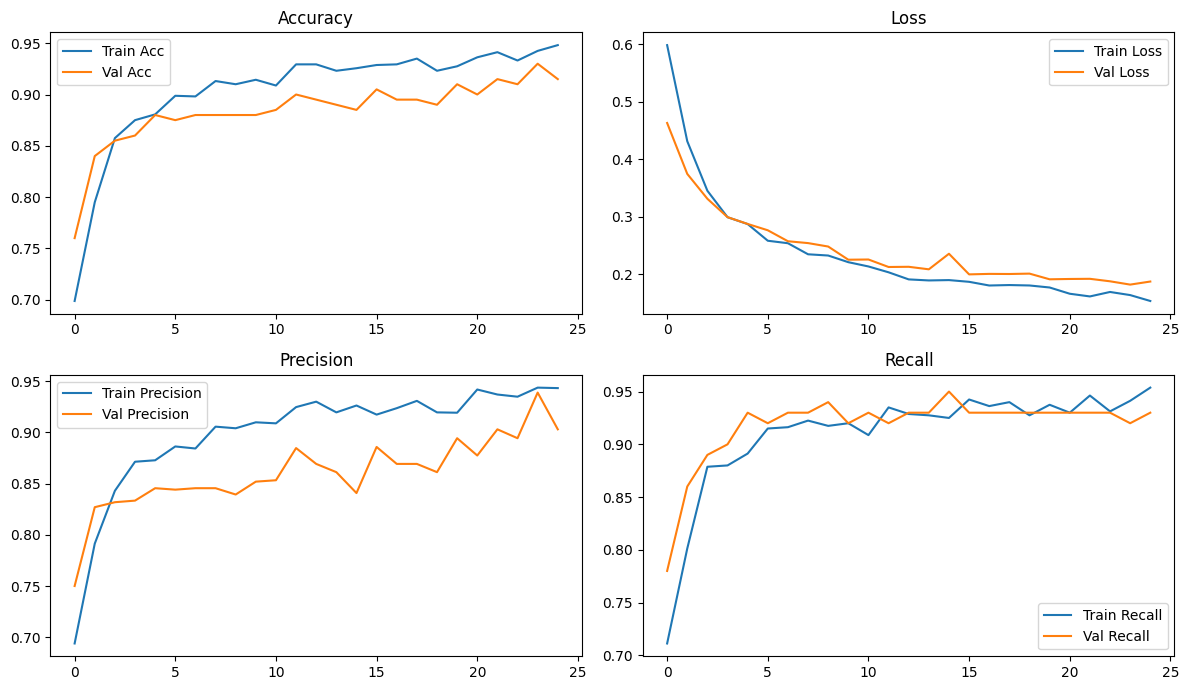

### 1.3 Test Results

> TEST DATASET

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 0.9200 - loss: 0.2019 - precision_1: 0.9667 - recall_1: 0.8700 

                precision    recall  f1-score   support

    non-recyclable   0.88      0.97      0.92       100
    recyclable       0.97      0.87      0.92       100

      accuracy                           0.92       200
     macro avg       0.92      0.92      0.92       200
  weighted avg       0.92      0.92      0.92       200

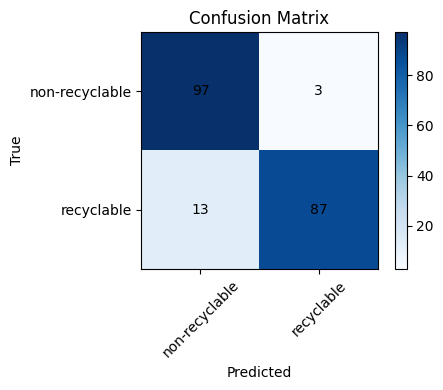

## Stage 2 Training

> **Note:** Stage 2 training logs and results are not available in this session.

## Stage 3: Paper — 01/24/2026

### Stage 3 Paper Summary

**Task:** Multi-class classification of paper sub-types (5 classes)  
**Classes:** mixed_paper, old_corrugated_cartons (OCC), old_newspaper, selected_white_ledger, used_beverage_carton  
**Dataset:** 250 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 38.3% | 93.8% | — |
| Val Accuracy | 73.6% | 93.2% | **93.2%** (Ep 22) |
| Train Loss | 1.6839 | — | — |
| Val Loss | 0.8154 | — | — |

**Insights:**
- Training accuracy started low (38%) due to 5-class complexity, but showed rapid improvement, particularly between epochs 1–8.
- Validation accuracy consistently exceeded training accuracy in early epochs, suggesting good generalization with the given data augmentation.
- Best validation epoch was **Epoch 22** (93.2% val accuracy).
- Test accuracy was **84.8%** — notably lower than best validation (93.2%), indicating some difficulty generalizing to unseen samples.
- `mixed_paper` had the lowest F1-score (0.72), while `used_beverage_carton` achieved near-perfect recall (1.00), making it the easiest to classify.

### 3a.1 Raw Training Logs

In [ ]:
Epoch 1/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.3830 - loss: 1.6839 - precision: 0.4345 - recall: 0.2620 - val_accuracy: 0.7360 - val_loss: 0.8154 - val_precision: 0.8544 - val_recall: 0.5400
Epoch 2/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.6565 - loss: 0.9114 - precision: 0.7305 - recall: 0.5625 - val_accuracy: 0.7920 - val_loss: 0.5850 - val_precision: 0.8889 - val_recall: 0.7040
Epoch 3/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7490 - loss: 0.7077 - precision: 0.8012 - recall: 0.6690 - val_accuracy: 0.8360 - val_loss: 0.4711 - val_precision: 0.8829 - val_recall: 0.7840
Epoch 4/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7810 - loss: 0.6077 - precision: 0.8307 - recall: 0.7235 - val_accuracy: 0.8680 - val_loss: 0.4134 - val_precision: 0.9027 - val_recall: 0.8160
Epoch 5/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8175 - loss: 0.5049 - precision: 0.8490 - recall: 0.7705 - val_accuracy: 0.8640 - val_loss: 0.3843 - val_precision: 0.8970 - val_recall: 0.8360
Epoch 6/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8285 - loss: 0.4728 - precision: 0.8685 - recall: 0.7860 - val_accuracy: 0.8600 - val_loss: 0.3559 - val_precision: 0.8861 - val_recall: 0.8400
Epoch 7/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8340 - loss: 0.4453 - precision: 0.8695 - recall: 0.7965 - val_accuracy: 0.8720 - val_loss: 0.3326 - val_precision: 0.8979 - val_recall: 0.8440
Epoch 8/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8675 - loss: 0.3823 - precision: 0.8929 - recall: 0.8340 - val_accuracy: 0.8840 - val_loss: 0.3228 - val_precision: 0.8963 - val_recall: 0.8640
Epoch 9/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8650 - loss: 0.3844 - precision: 0.8907 - recall: 0.8315 - val_accuracy: 0.8880 - val_loss: 0.2997 - val_precision: 0.9114 - val_recall: 0.8640
Epoch 10/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8760 - loss: 0.3495 - precision: 0.9030 - recall: 0.8475 - val_accuracy: 0.8840 - val_loss: 0.2964 - val_precision: 0.9076 - val_recall: 0.8640
Epoch 11/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8875 - loss: 0.3244 - precision: 0.9090 - recall: 0.8590 - val_accuracy: 0.9040 - val_loss: 0.2897 - val_precision: 0.9247 - val_recall: 0.8840
Epoch 12/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8935 - loss: 0.2972 - precision: 0.9143 - recall: 0.8745 - val_accuracy: 0.9120 - val_loss: 0.2776 - val_precision: 0.9325 - val_recall: 0.8840
Epoch 13/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8930 - loss: 0.2898 - precision: 0.9089 - recall: 0.8775 - val_accuracy: 0.9120 - val_loss: 0.2736 - val_precision: 0.9289 - val_recall: 0.8880
Epoch 14/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8940 - loss: 0.2730 - precision: 0.9189 - recall: 0.8785 - val_accuracy: 0.9240 - val_loss: 0.2638 - val_precision: 0.9331 - val_recall: 0.8920
Epoch 15/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9010 - loss: 0.2726 - precision: 0.9194 - recall: 0.8835 - val_accuracy: 0.9160 - val_loss: 0.2593 - val_precision: 0.9375 - val_recall: 0.9000
Epoch 16/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 491s 8s/step - accuracy: 0.9240 - loss: 0.2333 - precision: 0.9418 - recall: 0.9055 - val_accuracy: 0.9280 - val_loss: 0.2509 - val_precision: 0.9419 - val_recall: 0.9080
Epoch 17/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9125 - loss: 0.2338 - precision: 0.9290 - recall: 0.8960 - val_accuracy: 0.9240 - val_loss: 0.2473 - val_precision: 0.9300 - val_recall: 0.9040
Epoch 18/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.9155 - loss: 0.2249 - precision: 0.9278 - recall: 0.8990 - val_accuracy: 0.9160 - val_loss: 0.2497 - val_precision: 0.9298 - val_recall: 0.9000
Epoch 19/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9255 - loss: 0.2240 - precision: 0.9371 - recall: 0.9090 - val_accuracy: 0.9080 - val_loss: 0.2546 - val_precision: 0.9177 - val_recall: 0.8920
Epoch 20/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9300 - loss: 0.2033 - precision: 0.9404 - recall: 0.9150 - val_accuracy: 0.9280 - val_loss: 0.2348 - val_precision: 0.9309 - val_recall: 0.9160
Epoch 21/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9295 - loss: 0.2003 - precision: 0.9417 - recall: 0.9205 - val_accuracy: 0.9280 - val_loss: 0.2354 - val_precision: 0.9352 - val_recall: 0.9240
Epoch 22/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9335 - loss: 0.2041 - precision: 0.9441 - recall: 0.9210 - val_accuracy: 0.9320 - val_loss: 0.2357 - val_precision: 0.9347 - val_recall: 0.9160
Epoch 23/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9295 - loss: 0.1980 - precision: 0.9405 - recall: 0.9165 - val_accuracy: 0.9320 - val_loss: 0.2260 - val_precision: 0.9390 - val_recall: 0.9240
Epoch 24/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9380 - loss: 0.1844 - precision: 0.9495 - recall: 0.9310 - val_accuracy: 0.9280 - val_loss: 0.2364 - val_precision: 0.9355 - val_recall: 0.9280
Epoch 25/25
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9375 - loss: 0.1808 - precision: 0.9512 - recall: 0.9260 - val_accuracy: 0.9320 - val_loss: 0.2290 - val_precision: 0.9355 - val_recall: 0.9280

### 3a.2 Training Curves

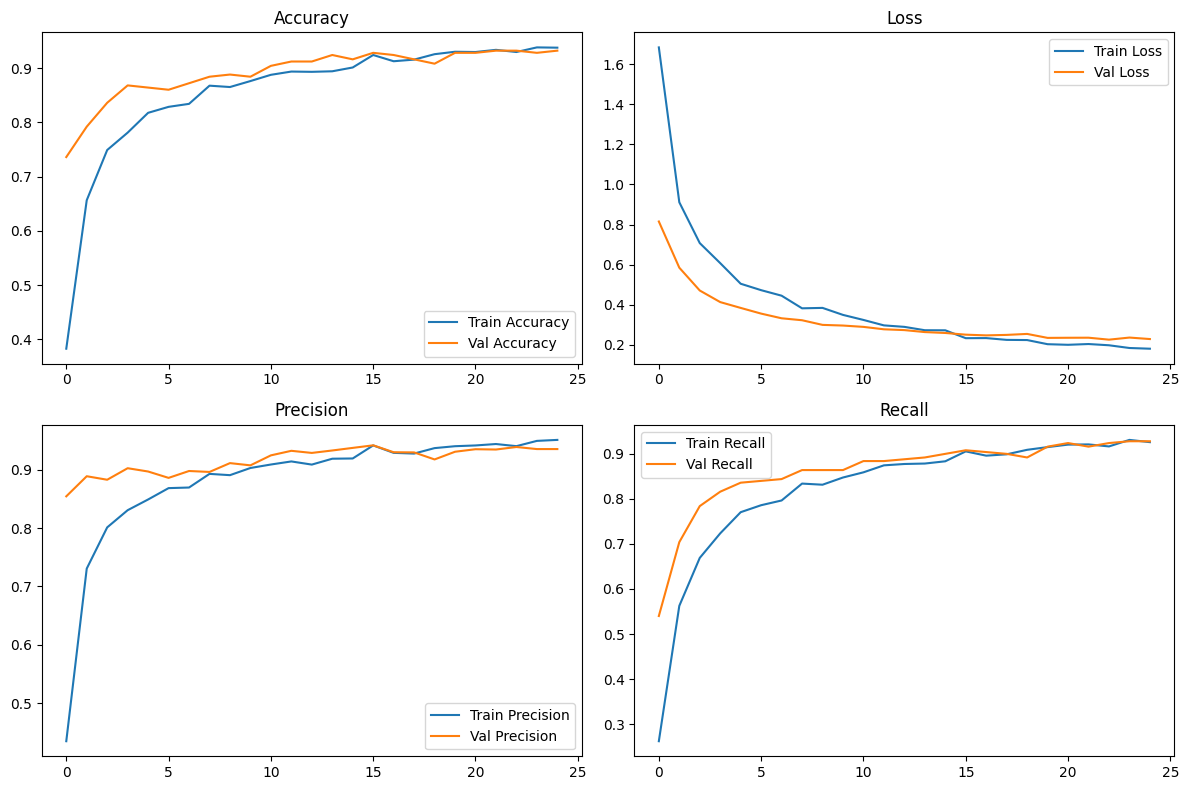

### 3a.3 Test Results

> TEST DATASET

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8480 - loss: 0.3669 - precision: 0.8636 - recall: 0.8360

8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

                        precision    recall  f1-score   support

            mixed_paper       0.66      0.78      0.72        50
    old_corrugated_cartons    0.91      0.96      0.93        50
            old_newspaper     0.90      0.74      0.81        50
    selected_white_ledger     0.83      0.76      0.79        50
    used_beverage_carton      0.98      1.00      0.99        50

              accuracy                           0.85       250
             macro avg       0.86      0.85      0.85       250
          weighted avg       0.86      0.85      0.85       250

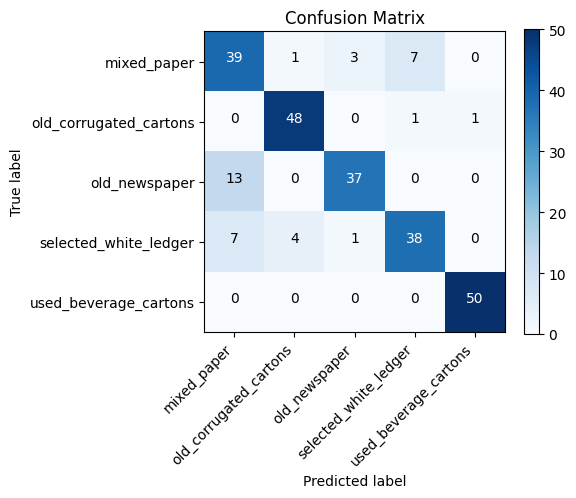

## Stage 3: Glass — 01/24/2026

### Stage 3 Glass Summary

**Task:** Multi-class classification of glass sub-types (3 classes)  
**Classes:** glass_bottles, glass_cullets, glass_flat_glass  
**Dataset:** 150 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 62.3% | 99.2% | — |
| Val Accuracy | 92.0% | 98.0% | **99.3%** (Ep 20) |
| Train Loss | 0.8892 | — | — |
| Val Loss | 0.2198 | — | — |

**Insights:**
- The model achieved very high validation accuracy from epoch 1 (92.0%), reflecting strong visual distinction between glass sub-types.
- Validation accuracy plateaued around 98–99% after epoch 7, showing early convergence.
- Best validation epoch was **Epoch 20** (99.3% val accuracy).
- Test accuracy was **98.7%**, closely matching validation — excellent generalization.
- All three classes scored F1 ≥ 0.98; `glass_flat_glass` achieved perfect precision (1.00).

### 3b.1 Raw Training Logs

In [ ]:
Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 918ms/step - accuracy: 0.6225 - loss: 0.8892 - precision: 0.6574 - recall: 0.5742 - val_accuracy: 0.9200 - val_loss: 0.2198 - val_precision: 0.9315 - val_recall: 0.9067
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9033 - loss: 0.2851 - precision: 0.9185 - recall: 0.8833 - val_accuracy: 0.9400 - val_loss: 0.1396 - val_precision: 0.9463 - val_recall: 0.9400
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9300 - loss: 0.2058 - precision: 0.9350 - recall: 0.9233 - val_accuracy: 0.9533 - val_loss: 0.1058 - val_precision: 0.9527 - val_recall: 0.9400
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 912ms/step - accuracy: 0.9425 - loss: 0.1536 - precision: 0.9492 - recall: 0.9342 - val_accuracy: 0.9667 - val_loss: 0.0805 - val_precision: 0.9664 - val_recall: 0.9600
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 938ms/step - accuracy: 0.9517 - loss: 0.1277 - precision: 0.9571 - recall: 0.9492 - val_accuracy: 0.9667 - val_loss: 0.0643 - val_precision: 0.9732 - val_recall: 0.9667
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 929ms/step - accuracy: 0.9617 - loss: 0.1130 - precision: 0.9655 - recall: 0.9567 - val_accuracy: 0.9800 - val_loss: 0.0569 - val_precision: 0.9799 - val_recall: 0.9733
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 999ms/step - accuracy: 0.9742 - loss: 0.0890 - precision: 0.9741 - recall: 0.9708 - val_accuracy: 0.9867 - val_loss: 0.0465 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 913ms/step - accuracy: 0.9658 - loss: 0.0995 - precision: 0.9673 - recall: 0.9625 - val_accuracy: 0.9867 - val_loss: 0.0447 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 9/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 969ms/step - accuracy: 0.9692 - loss: 0.0820 - precision: 0.9716 - recall: 0.9683 - val_accuracy: 0.9867 - val_loss: 0.0435 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 10/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 936ms/step - accuracy: 0.9750 - loss: 0.0802 - precision: 0.9773 - recall: 0.9708 - val_accuracy: 0.9867 - val_loss: 0.0416 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 11/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 37s 984ms/step - accuracy: 0.9733 - loss: 0.0740 - precision: 0.9757 - recall: 0.9708 - val_accuracy: 0.9867 - val_loss: 0.0367 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 12/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9825 - loss: 0.0609 - precision: 0.9849 - recall: 0.9817 - val_accuracy: 0.9867 - val_loss: 0.0382 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 13/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9875 - loss: 0.0467 - precision: 0.9875 - recall: 0.9858 - val_accuracy: 0.9867 - val_loss: 0.0338 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 14/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9867 - loss: 0.0448 - precision: 0.9875 - recall: 0.9858 - val_accuracy: 0.9867 - val_loss: 0.0331 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 15/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9850 - loss: 0.0478 - precision: 0.9858 - recall: 0.9817 - val_accuracy: 0.9867 - val_loss: 0.0309 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 16/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9875 - loss: 0.0420 - precision: 0.9891 - recall: 0.9867 - val_accuracy: 0.9800 - val_loss: 0.0318 - val_precision: 0.9800 - val_recall: 0.9800
Epoch 17/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9900 - loss: 0.0368 - precision: 0.9916 - recall: 0.9875 - val_accuracy: 0.9800 - val_loss: 0.0317 - val_precision: 0.9800 - val_recall: 0.9800
Epoch 18/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 36s 962ms/step - accuracy: 0.9900 - loss: 0.0399 - precision: 0.9908 - recall: 0.9883 - val_accuracy: 0.9867 - val_loss: 0.0265 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 19/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9867 - loss: 0.0389 - precision: 0.9883 - recall: 0.9867 - val_accuracy: 0.9800 - val_loss: 0.0261 - val_precision: 0.9800 - val_recall: 0.9800
Epoch 20/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 910ms/step - accuracy: 0.9883 - loss: 0.0379 - precision: 0.9883 - recall: 0.9883 - val_accuracy: 0.9933 - val_loss: 0.0241 - val_precision: 0.9933 - val_recall: 0.9933
Epoch 21/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 879ms/step - accuracy: 0.9942 - loss: 0.0259 - precision: 0.9950 - recall: 0.9933 - val_accuracy: 0.9867 - val_loss: 0.0261 - val_precision: 0.9866 - val_recall: 0.9800
Epoch 22/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 864ms/step - accuracy: 0.9892 - loss: 0.0282 - precision: 0.9900 - recall: 0.9883 - val_accuracy: 0.9933 - val_loss: 0.0221 - val_precision: 0.9933 - val_recall: 0.9933
Epoch 23/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 847ms/step - accuracy: 0.9950 - loss: 0.0222 - precision: 0.9958 - recall: 0.9950 - val_accuracy: 0.9867 - val_loss: 0.0228 - val_precision: 0.9867 - val_recall: 0.9867
Epoch 24/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 827ms/step - accuracy: 0.9975 - loss: 0.0164 - precision: 0.9975 - recall: 0.9975 - val_accuracy: 0.9800 - val_loss: 0.0236 - val_precision: 0.9800 - val_recall: 0.9800
Epoch 25/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 862ms/step - accuracy: 0.9917 - loss: 0.0284 - precision: 0.9917 - recall: 0.9917 - val_accuracy: 0.9800 - val_loss: 0.0228 - val_precision: 0.9866 - val_recall: 0.9800

### 3b.2 Training Curves

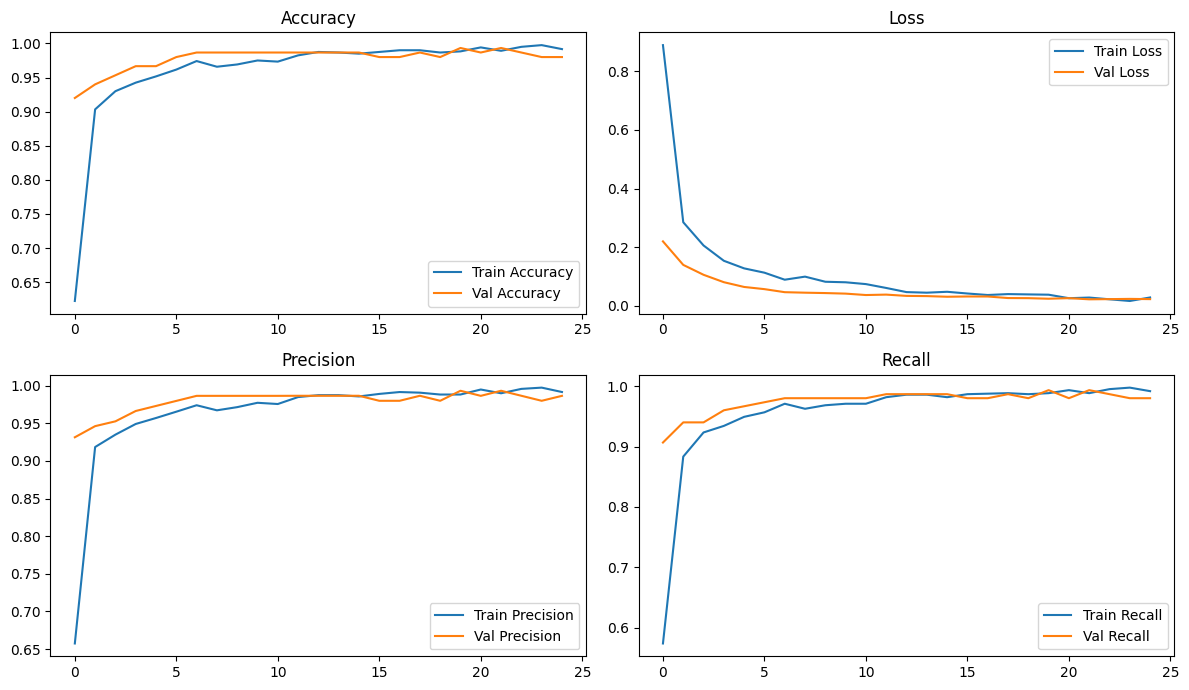

### 3b.3 Test Results

> TEST DATASET

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 572ms/step - accuracy: 0.9867 - loss: 0.0356 - precision: 0.9867 - recall: 0.9867

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 845ms/step

                  precision    recall  f1-score   support


    glass_bottles       0.98      1.00      0.99        50
    glass_cullets       0.98      0.98      0.98        50
    glass_flat_glass    1.00      0.98      0.99        50

        accuracy                           0.99       150
       macro avg       0.99      0.99      0.99       150
    weighted avg       0.99      0.99      0.99       150

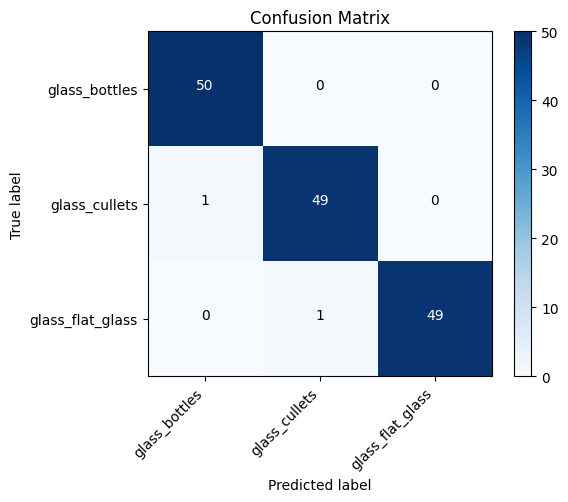

## Stage 3: Residual — 01/24/2026

### Stage 3 Residual Summary

**Task:** Multi-class classification of residual sub-types (4 classes)  
**Classes:** clean_and_dry_flexible_plastics, leather, rubber, textiles  
**Dataset:** 200 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 48.1% | 97.1% | — |
| Val Accuracy | 85.5% | 96.5% | **97.5%** (Ep 24) |
| Train Loss | 1.3629 | — | — |
| Val Loss | 0.5566 | — | — |

**Insights:**
- Training started with moderate accuracy (48%) but improved rapidly, crossing 90% before epoch 10.
- Validation accuracy closely tracked training throughout, indicating minimal overfitting.
- Best validation epoch was **Epoch 24** (97.5% val accuracy), with the model still improving at the end of training.
- Test accuracy was **96.5%**, closely matching the final validation accuracy.
- `clean_and_dry_flexible_plastics` and `textiles` achieved perfect F1-scores (1.00); `rubber` and `leather` showed slightly lower but still strong scores.

### 3c.1 Raw Training Logs

In [ ]:
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.4812 - loss: 1.3629 - precision: 0.5324 - recall: 0.3850 - val_accuracy: 0.8550 - val_loss: 0.5566 - val_precision: 0.8970 - val_recall: 0.7400
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7725 - loss: 0.6254 - precision: 0.8226 - recall: 0.7156 - val_accuracy: 0.8950 - val_loss: 0.3570 - val_precision: 0.9259 - val_recall: 0.8750
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8537 - loss: 0.4705 - precision: 0.8739 - recall: 0.8144 - val_accuracy: 0.9200 - val_loss: 0.2703 - val_precision: 0.9415 - val_recall: 0.8850
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8756 - loss: 0.3448 - precision: 0.9028 - recall: 0.8587 - val_accuracy: 0.9150 - val_loss: 0.2253 - val_precision: 0.9375 - val_recall: 0.9000
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8981 - loss: 0.2958 - precision: 0.9087 - recall: 0.8775 - val_accuracy: 0.9400 - val_loss: 0.1996 - val_precision: 0.9433 - val_recall: 0.9150
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9175 - loss: 0.2484 - precision: 0.9299 - recall: 0.9038 - val_accuracy: 0.9300 - val_loss: 0.1961 - val_precision: 0.9436 - val_recall: 0.9200
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9200 - loss: 0.2291 - precision: 0.9308 - recall: 0.9075 - val_accuracy: 0.9450 - val_loss: 0.1647 - val_precision: 0.9442 - val_recall: 0.9300
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9181 - loss: 0.2066 - precision: 0.9298 - recall: 0.9112 - val_accuracy: 0.9500 - val_loss: 0.1527 - val_precision: 0.9543 - val_recall: 0.9400
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9413 - loss: 0.1748 - precision: 0.9486 - recall: 0.9344 - val_accuracy: 0.9550 - val_loss: 0.1387 - val_precision: 0.9598 - val_recall: 0.9550
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9438 - loss: 0.1709 - precision: 0.9494 - recall: 0.9381 - val_accuracy: 0.9500 - val_loss: 0.1340 - val_precision: 0.9500 - val_recall: 0.9500
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9425 - loss: 0.1710 - precision: 0.9467 - recall: 0.9331 - val_accuracy: 0.9550 - val_loss: 0.1253 - val_precision: 0.9646 - val_recall: 0.9550
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9369 - loss: 0.1600 - precision: 0.9460 - recall: 0.9300 - val_accuracy: 0.9600 - val_loss: 0.1217 - val_precision: 0.9648 - val_recall: 0.9600
Epoch 13/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9469 - loss: 0.1536 - precision: 0.9524 - recall: 0.9388 - val_accuracy: 0.9600 - val_loss: 0.1110 - val_precision: 0.9697 - val_recall: 0.9600
Epoch 14/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9556 - loss: 0.1337 - precision: 0.9596 - recall: 0.9494 - val_accuracy: 0.9700 - val_loss: 0.1098 - val_precision: 0.9698 - val_recall: 0.9650
Epoch 15/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9556 - loss: 0.1281 - precision: 0.9614 - recall: 0.9500 - val_accuracy: 0.9700 - val_loss: 0.1102 - val_precision: 0.9698 - val_recall: 0.9650
Epoch 16/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9581 - loss: 0.1257 - precision: 0.9645 - recall: 0.9513 - val_accuracy: 0.9650 - val_loss: 0.1114 - val_precision: 0.9746 - val_recall: 0.9600
Epoch 17/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9544 - loss: 0.1172 - precision: 0.9591 - recall: 0.9525 - val_accuracy: 0.9700 - val_loss: 0.1019 - val_precision: 0.9747 - val_recall: 0.9650
Epoch 18/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9575 - loss: 0.1213 - precision: 0.9597 - recall: 0.9519 - val_accuracy: 0.9700 - val_loss: 0.1095 - val_precision: 0.9747 - val_recall: 0.9650
Epoch 19/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9625 - loss: 0.1088 - precision: 0.9660 - recall: 0.9600 - val_accuracy: 0.9700 - val_loss: 0.1050 - val_precision: 0.9747 - val_recall: 0.9650
Epoch 20/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9656 - loss: 0.1112 - precision: 0.9679 - recall: 0.9606 - val_accuracy: 0.9700 - val_loss: 0.0983 - val_precision: 0.9747 - val_recall: 0.9650
Epoch 21/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9631 - loss: 0.0948 - precision: 0.9672 - recall: 0.9575 - val_accuracy: 0.9700 - val_loss: 0.0962 - val_precision: 0.9747 - val_recall: 0.9650
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9638 - loss: 0.0981 - precision: 0.9679 - recall: 0.9613 - val_accuracy: 0.9700 - val_loss: 0.0857 - val_precision: 0.9700 - val_recall: 0.9700
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9712 - loss: 0.0849 - precision: 0.9730 - recall: 0.9694 - val_accuracy: 0.9700 - val_loss: 0.0836 - val_precision: 0.9698 - val_recall: 0.9650
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9631 - loss: 0.0905 - precision: 0.9649 - recall: 0.9613 - val_accuracy: 0.9750 - val_loss: 0.0859 - val_precision: 0.9798 - val_recall: 0.9700
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9706 - loss: 0.0815 - precision: 0.9736 - recall: 0.9694 - val_accuracy: 0.9650 - val_loss: 0.0882 - val_precision: 0.9650 - val_recall: 0.9650

### 3c.2 Training Curves

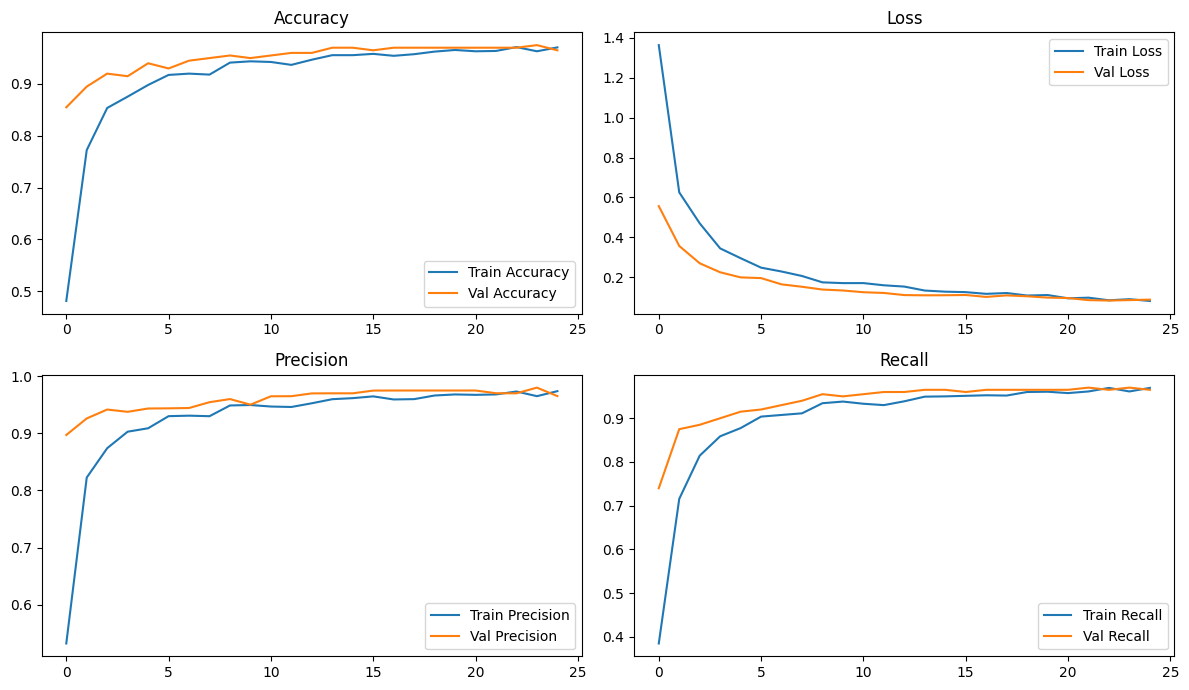

### 3c.3 Test Results

> TEST DATASET

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 993ms/step - accuracy: 0.9650 - loss: 0.0816 - precision: 0.9650 - recall: 0.9650

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step 

                                 precision    recall  f1-score   support

    clean_and_dry_flexible_plastics   1.00      1.00      1.00        50
                        leather       0.91      0.96      0.93        50
                        rubber        0.96      0.90      0.93        50
                        textiles      1.00      1.00      1.00        50

                       accuracy                           0.96       200
                      macro avg       0.97      0.96      0.96       200
                   weighted avg       0.97      0.96      0.96       200

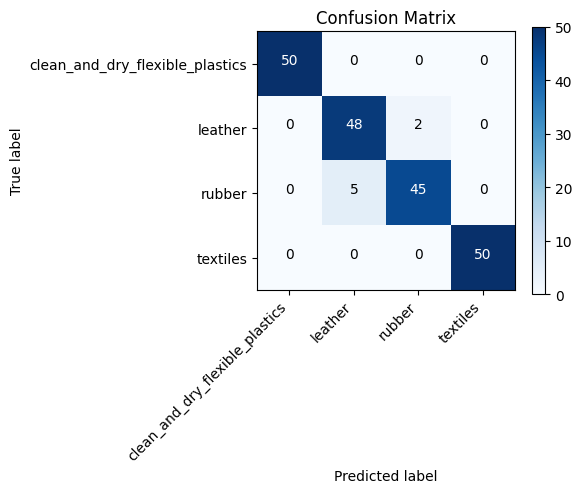

## Stage 3: Metal — 01/24/2026

### Stage 3 Metal Summary

**Task:** Multi-class classification of metal sub-types (3 classes)  
**Classes:** aluminum_tin, copper, steel  
**Dataset:** 150 test samples (50 per class)

| Metric | Epoch 1 | Final (Ep 25) | Best Val |
|--------|---------|--------------|----------|
| Train Accuracy | 49.2% | 98.1% | — |
| Val Accuracy | 85.3% | 96.7% | **96.7%** (Ep 25) |
| Train Loss | 1.2569 | — | — |
| Val Loss | 0.4581 | — | — |

**Insights:**
- Training started modestly (49%) but climbed steeply, reaching 93% by epoch 10.
- Validation accuracy was still improving at epoch 25 (best val epoch = 25), suggesting the model could benefit from additional training epochs.
- Test accuracy was **97.3%**, slightly *exceeding* the best validation accuracy — indicating very good generalization.
- `aluminum_tin` achieved a perfect F1-score (1.00); `copper` and `steel` had slight confusion between each other (0.96 F1).

### 3d.1 Raw Training Logs

In [ ]:
Epoch 1/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m52s[0m 1s/step - accuracy: 0.4917 - loss: 1.2569 - precision: 0.5143 - recall: 0.4483 - val_accuracy: 0.8533 - val_loss: 0.4581 - val_precision: 0.8777 - val_recall: 0.8133
Epoch 2/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m37s[0m 963ms/step - accuracy: 0.7600 - loss: 0.5848 - precision: 0.7786 - recall: 0.7267 - val_accuracy: 0.9133 - val_loss: 0.2986 - val_precision: 0.9441 - val_recall: 0.9000
Epoch 3/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m37s[0m 963ms/step - accuracy: 0.8342 - loss: 0.4149 - precision: 0.8462 - recall: 0.8158 - val_accuracy: 0.9400 - val_loss: 0.2308 - val_precision: 0.9524 - val_recall: 0.9333
Epoch 4/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m36s[0m 938ms/step - accuracy: 0.8808 - loss: 0.3063 - precision: 0.8921 - recall: 0.8683 - val_accuracy: 0.9533 - val_loss: 0.1931 - val_precision: 0.9592 - val_recall: 0.9400
Epoch 5/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m39s[0m 1s/step - accuracy: 0.8783 - loss: 0.2880 - precision: 0.8910 - recall: 0.8717 - val_accuracy: 0.9467 - val_loss: 0.1720 - val_precision: 0.9595 - val_recall: 0.9467
Epoch 6/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m36s[0m 960ms/step - accuracy: 0.9200 - loss: 0.2261 - precision: 0.9307 - recall: 0.9175 - val_accuracy: 0.9333 - val_loss: 0.1703 - val_precision: 0.9396 - val_recall: 0.9333
Epoch 7/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m37s[0m 985ms/step - accuracy: 0.9250 - loss: 0.1922 - precision: 0.9361 - recall: 0.9158 - val_accuracy: 0.9467 - val_loss: 0.1435 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 8/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 928ms/step - accuracy: 0.9333 - loss: 0.1866 - precision: 0.9377 - recall: 0.9275 - val_accuracy: 0.9400 - val_loss: 0.1405 - val_precision: 0.9400 - val_recall: 0.9400
Epoch 9/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m38s[0m 999ms/step - accuracy: 0.9433 - loss: 0.1661 - precision: 0.9479 - recall: 0.9400 - val_accuracy: 0.9467 - val_loss: 0.1360 - val_precision: 0.9467 - val_recall: 0.9467
Epoch 10/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m37s[0m 975ms/step - accuracy: 0.9392 - loss: 0.1607 - precision: 0.9412 - recall: 0.9333 - val_accuracy: 0.9400 - val_loss: 0.1391 - val_precision: 0.9400 - val_recall: 0.9400
Epoch 11/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m139s[0m 4s/step - accuracy: 0.9475 - loss: 0.1475 - precision: 0.9505 - recall: 0.9450 - val_accuracy: 0.9467 - val_loss: 0.1335 - val_precision: 0.9467 - val_recall: 0.9467
Epoch 12/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 910ms/step - accuracy: 0.9500 - loss: 0.1363 - precision: 0.9530 - recall: 0.9467 - val_accuracy: 0.9467 - val_loss: 0.1290 - val_precision: 0.9467 - val_recall: 0.9467
Epoch 13/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m41s[0m 921ms/step - accuracy: 0.9600 - loss: 0.1113 - precision: 0.9631 - recall: 0.9567 - val_accuracy: 0.9467 - val_loss: 0.1188 - val_precision: 0.9467 - val_recall: 0.9467
Epoch 14/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m34s[0m 903ms/step - accuracy: 0.9600 - loss: 0.1042 - precision: 0.9647 - recall: 0.9575 - val_accuracy: 0.9467 - val_loss: 0.1217 - val_precision: 0.9467 - val_recall: 0.9467
Epoch 15/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m38s[0m 1s/step - accuracy: 0.9592 - loss: 0.1160 - precision: 0.9592 - recall: 0.9592 - val_accuracy: 0.9467 - val_loss: 0.1203 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 16/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 932ms/step - accuracy: 0.9708 - loss: 0.0908 - precision: 0.9732 - recall: 0.9683 - val_accuracy: 0.9467 - val_loss: 0.1196 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 17/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m36s[0m 941ms/step - accuracy: 0.9583 - loss: 0.1033 - precision: 0.9606 - recall: 0.9558 - val_accuracy: 0.9467 - val_loss: 0.1152 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 18/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m36s[0m 934ms/step - accuracy: 0.9667 - loss: 0.0883 - precision: 0.9715 - recall: 0.9658 - val_accuracy: 0.9467 - val_loss: 0.1201 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 19/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m298s[0m 8s/step - accuracy: 0.9667 - loss: 0.0909 - precision: 0.9666 - recall: 0.9658 - val_accuracy: 0.9467 - val_loss: 0.1174 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 20/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m33s[0m 881ms/step - accuracy: 0.9758 - loss: 0.0800 - precision: 0.9766 - recall: 0.9750 - val_accuracy: 0.9467 - val_loss: 0.1158 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 21/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m34s[0m 884ms/step - accuracy: 0.9700 - loss: 0.0842 - precision: 0.9724 - recall: 0.9692 - val_accuracy: 0.9533 - val_loss: 0.1106 - val_precision: 0.9597 - val_recall: 0.9533
Epoch 22/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 928ms/step - accuracy: 0.9767 - loss: 0.0779 - precision: 0.9799 - recall: 0.9750 - val_accuracy: 0.9467 - val_loss: 0.1182 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 23/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 920ms/step - accuracy: 0.9775 - loss: 0.0657 - precision: 0.9799 - recall: 0.9758 - val_accuracy: 0.9533 - val_loss: 0.1138 - val_precision: 0.9597 - val_recall: 0.9533
Epoch 24/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 923ms/step - accuracy: 0.9817 - loss: 0.0623 - precision: 0.9833 - recall: 0.9808 - val_accuracy: 0.9533 - val_loss: 0.1177 - val_precision: 0.9530 - val_recall: 0.9467
Epoch 25/25
[1m38/38[0m [32m━━━━━━━━━━━━━━━━━━━━[0m[37m[0m [1m35s[0m 918ms/step - accuracy: 0.9808 - loss: 0.0616 - precision: 0.9817 - recall: 0.9808 - val_accuracy: 0.9667 - val_loss: 0.1115 - val_precision: 0.9664 - val_recall: 0.9600

### 3d.2 Training Curves

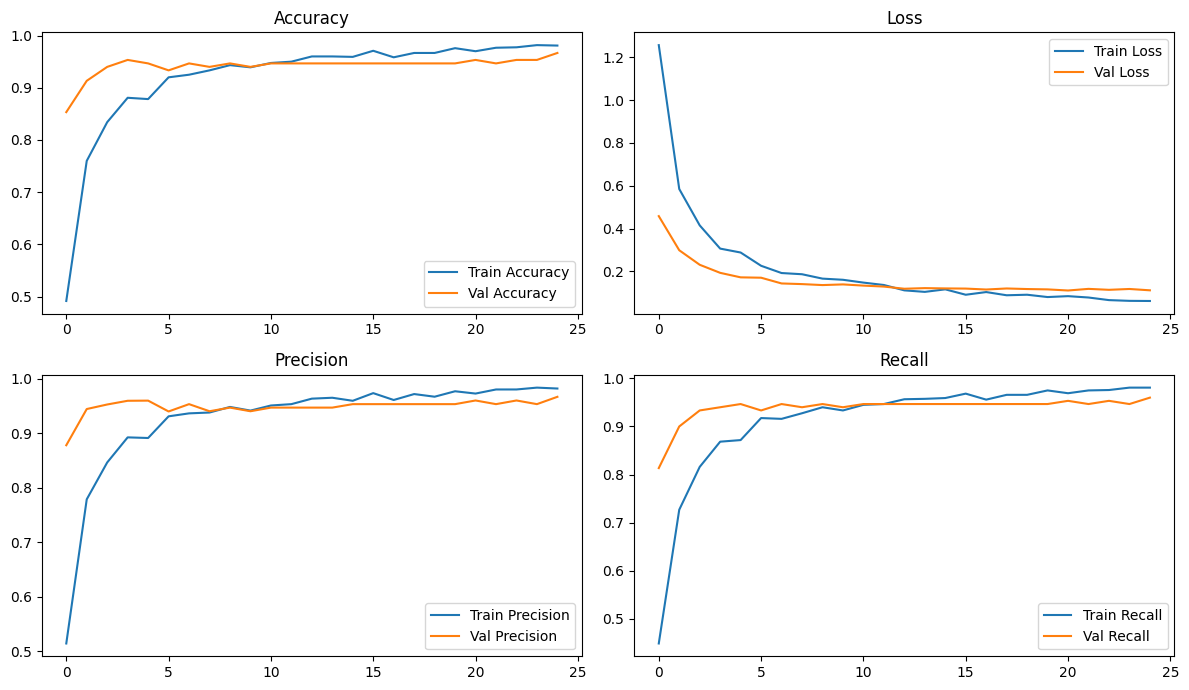

### 3d.3 Test Results

> TEST DATASET

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 586ms/step - accuracy: 0.9733 - loss: 0.0695 - precision: 0.9799 - recall: 0.9733

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  

              precision    recall  f1-score   support

    aluminum_tin   1.00      1.00      1.00        50
    copper         0.94      0.98      0.96        50
    steel          0.98      0.94      0.96        50

    accuracy                           0.97       150
    macro avg       0.97      0.97     0.97       150
    weighted avg    0.97      0.97     0.97       150

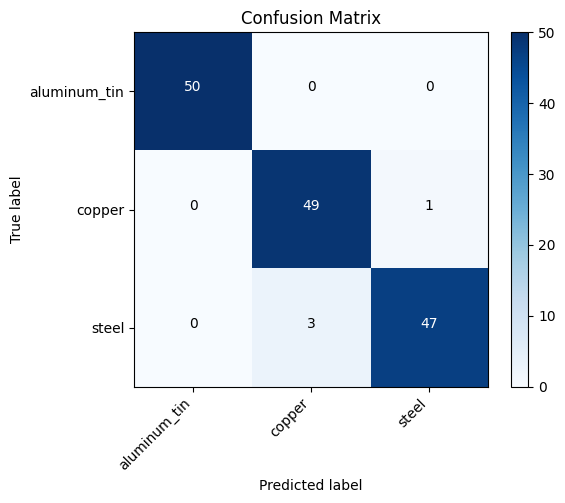